---
# **.vtk & 3D Rendering**
## This is the .ipynb file for things that are related to .vtk's.

Cooper Richman  
Professor Sang Hyun Lee  
University of Massachusetts Amherst Biofluids Lab  
9 February 2026  



---

## Change Log
2/9/2026: This file was created with parts of other files that have been collected in one area -C. Richman  
5/20/2026: I am trying to tidy things up -C. Richman


---

## **.vtk Plotting**

## A simple script to view one .vtk file in a 3D interactive window

In [2]:
# Import toolboxes to help
import pyvista as pv
from pathlib import Path

# This can changed to any .vtk file to be viewed
vtk_path = Path(r"..\Data\Cleaned .vtk's\pos1_frame000014.vtk_cleaned_with_tol=1.5.vtk")

# Load the .vtk
mesh = pv.read(vtk_path)
mesh = mesh.extract_surface().clean()

# Create the plotter object and add some settings
plotter = pv.Plotter(notebook=False, window_size=(900, 900))

plotter.add_mesh(
    mesh,
    color="lightblue",
    lighting=True,
    smooth_shading=False,
    show_edges=False,
    ambient=0.25,
    diffuse=0.7,
    specular=0.1
)

plotter.set_background("white")

# 3D grid box without units for clarity
plotter.show_grid(
    xlabel="X",
    ylabel="Y",
    zlabel="Z",
    show_zlabels=False,
    show_xlabels=False,
    show_ylabels=False
)
plotter.enable_eye_dome_lighting()
plotter.camera_position = "iso"
plotter.show_axes()

plotter.show()

## Cleaning the .vtk's with variable tolerance
### This cleans them and shows a resulting 3D screenshot
### The .vtk's nearby vertices are welded and then only the largest connected component is taken. Note that this cell does **not** save the results. The next cell does.

Processing: ChannelFITC,TD_Seq0001_pos1_ch1_frame000001.vtk


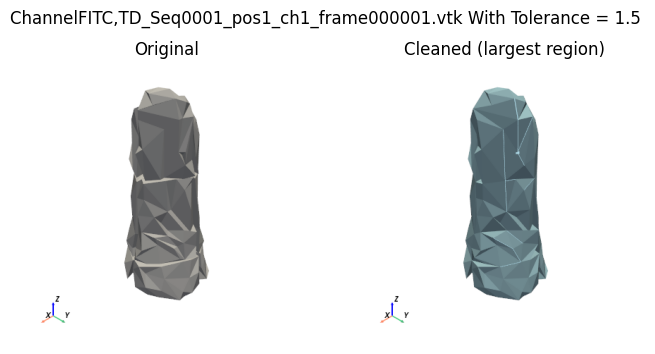

Processing: ChannelFITC,TD_Seq0001_pos1_ch1_frame000002.vtk


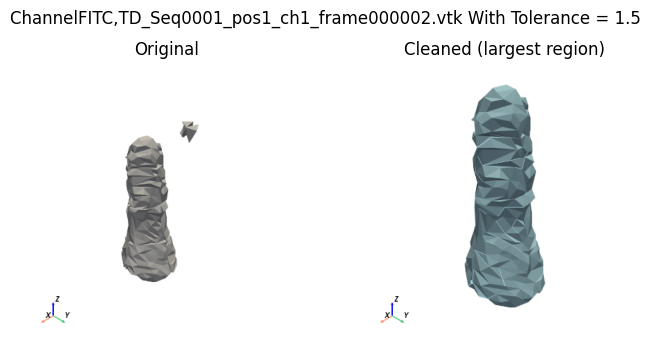

Processing: ChannelFITC,TD_Seq0001_pos1_ch1_frame000003.vtk


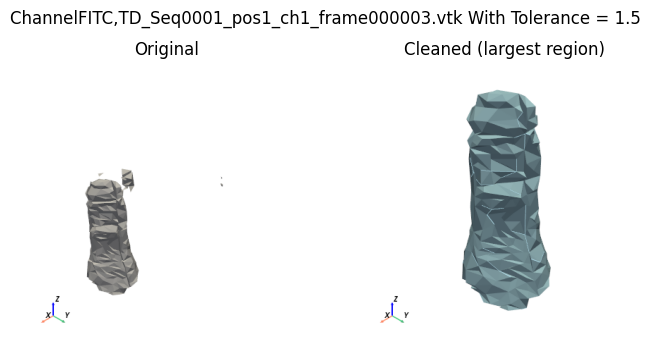

Processing: ChannelFITC,TD_Seq0001_pos1_ch1_frame000004.vtk


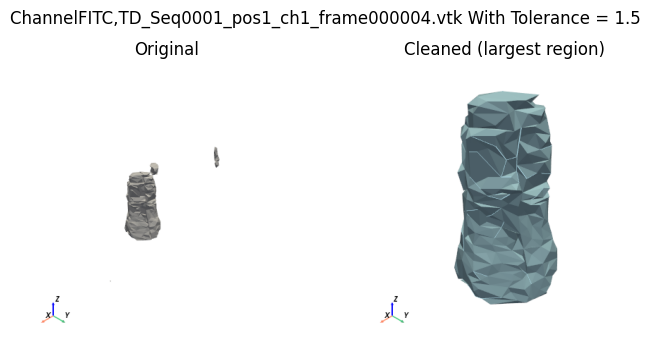

Processing: ChannelFITC,TD_Seq0001_pos1_ch1_frame000005.vtk


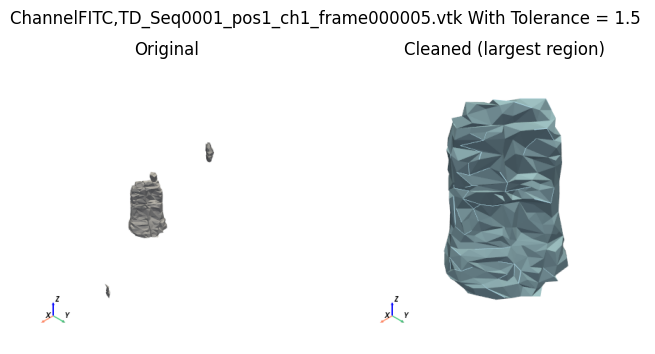

Processing: ChannelFITC,TD_Seq0001_pos1_ch1_frame000006.vtk


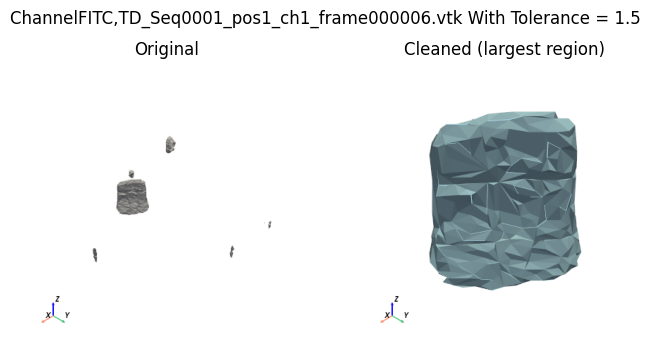

Processing: ChannelFITC,TD_Seq0001_pos1_ch1_frame000007.vtk


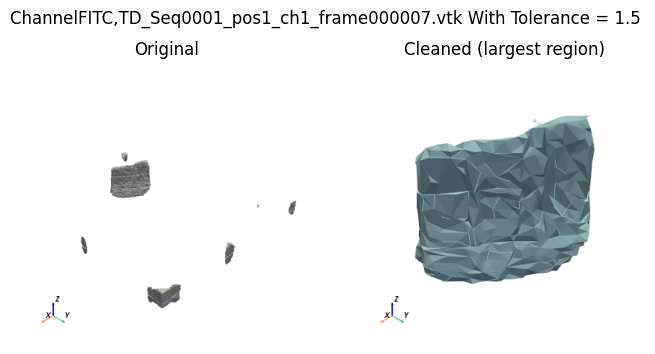

Processing: ChannelFITC,TD_Seq0001_pos1_ch1_frame000008.vtk


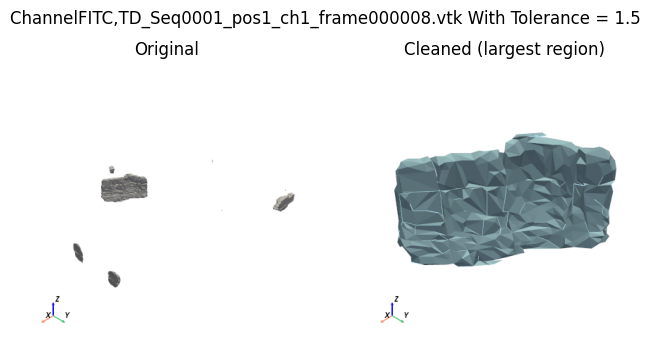

Processing: ChannelFITC,TD_Seq0001_pos1_ch1_frame000009.vtk


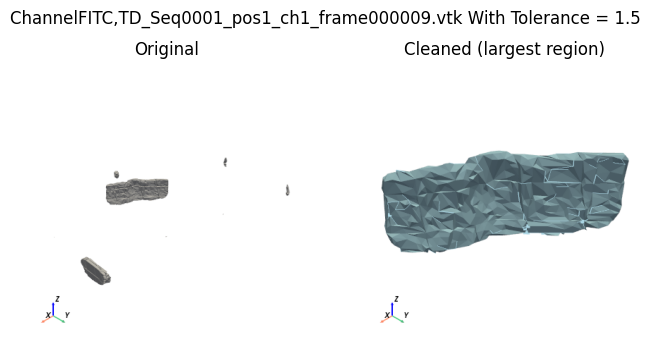

Processing: ChannelFITC,TD_Seq0001_pos1_ch1_frame000010.vtk


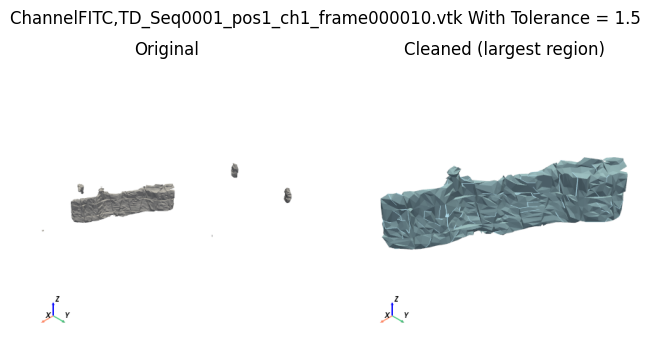

Processing: ChannelFITC,TD_Seq0001_pos1_ch1_frame000011.vtk


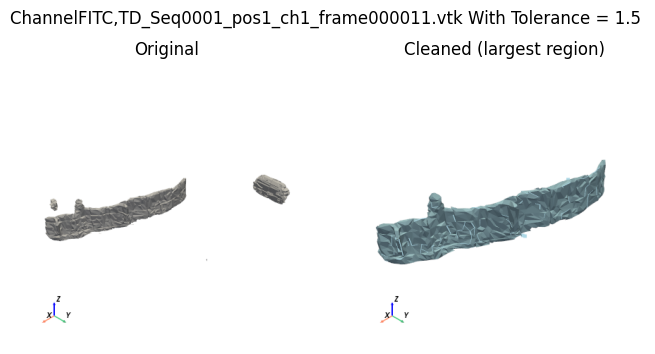

Processing: ChannelFITC,TD_Seq0001_pos1_ch1_frame000012.vtk


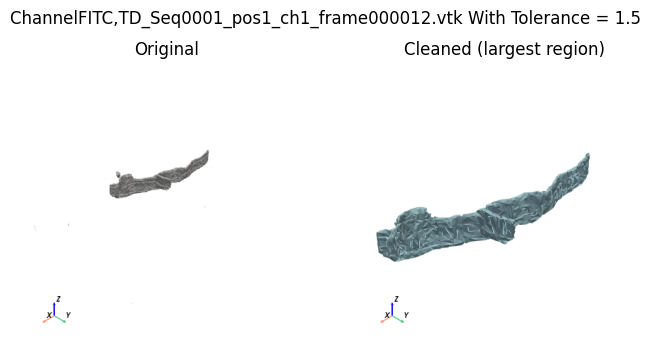

Processing: ChannelFITC,TD_Seq0001_pos1_ch1_frame000013.vtk


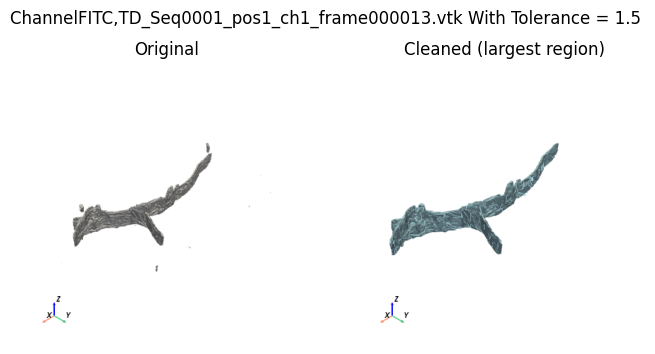

Processing: ChannelFITC,TD_Seq0001_pos1_ch1_frame000014.vtk


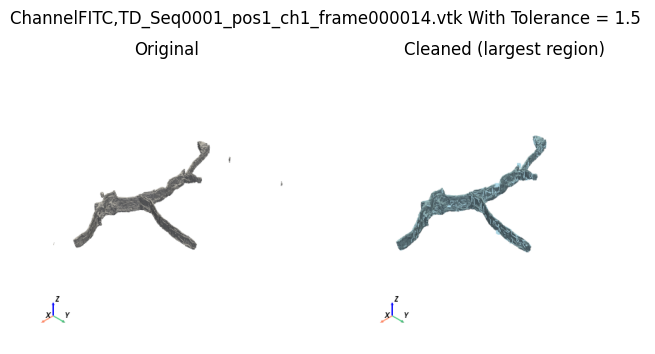

Processing: ChannelFITC,TD_Seq0001_pos1_ch1_frame000015.vtk


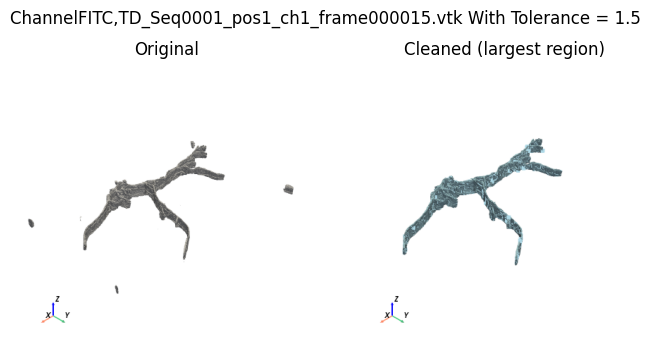

Processing: ChannelFITC,TD_Seq0001_pos1_ch1_frame000016.vtk


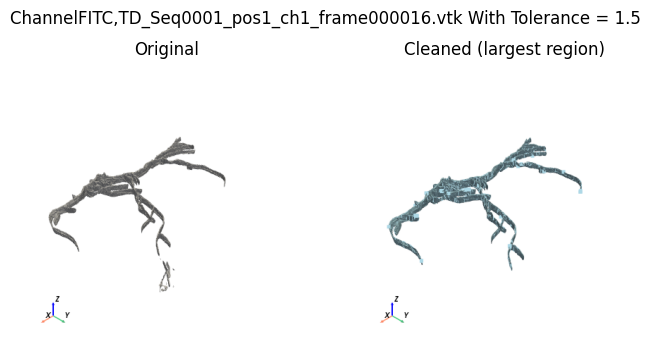

In [8]:
# Import toolboxes to help
import pyvista as pv
import matplotlib.pyplot as plt
import os

# Change the directory to use different .vtk files
# Note that this should point to the folder, not any specific file
vtk_dir = Path(r"..\Data\Raw .vtk's")
vtk_files = [f for f in os.listdir(vtk_dir) if f.endswith(".vtk")]

# --- Explanation of "tolerance" ---
# When using this script, it will merge vertices that are near one another to create one cohesive shape
# As a result, it needs to know how large its radius to merge should be
# This radius is set in units by the "tolerance" variable seen here
tolerance = 1.5  # Increase if faces still appear disconnected
window_size = (400, 400)  # Smaller static 3D rendering

# Loop through them and processs them
for file in vtk_files:
    path = os.path.join(vtk_dir, file)
    print(f"Processing: {file}")

    mesh = pv.read(path)

    # Weld nearby vertices
    welded = mesh.clean(tolerance=tolerance)

    # Keep only largest contiguous region
    cleaned = welded.connectivity(extraction_mode='largest')

    # --- Off-screen rendering to images ---
    img_orig = mesh.plot(
        color="lightgray",
        show_edges=False,
        notebook=False,
        cpos="iso",
        off_screen=True,
        window_size=window_size,
        screenshot=True  # returns np.ndarray image
    )

    img_clean = cleaned.plot(
        color="lightblue",
        show_edges=False,
        notebook=False,
        cpos="iso",
        off_screen=True,
        window_size=window_size,
        screenshot=True
    )

    # --- Display side-by-side in matplotlib ---
    fig, axs = plt.subplots(1, 2, figsize=(8, 4))
    axs[0].imshow(img_orig)
    axs[0].axis('off')
    axs[0].set_title("Original")
    axs[1].imshow(img_clean)
    axs[1].axis('off')
    axs[1].set_title("Cleaned (largest region)")
    plt.suptitle(file + f" With Tolerance = {tolerance}")
    plt.show()


## This cleans the .vtk data in the same way as above and then saves it
### Ensure to change the input and output directory as to not overwrite anything

In [5]:
# Import required libraries
import pyvista as pv
import os
from pathlib import Path

# ------------------------------------------------------------------
# INPUT DIRECTORY
#
# Folder containing the raw .vtk files to be cleaned.
# Change this path as needed when working with a different dataset.
# ------------------------------------------------------------------
vtk_dir = Path(r"..\Data\Raw .vtk's")

# Find all .vtk files in the directory
vtk_files = [f for f in os.listdir(vtk_dir) if f.endswith(".vtk")]

# ------------------------------------------------------------------
# WELDING TOLERANCE
#
# Vertices closer together than this distance will be merged.
# Increasing the value will connect more nearby surfaces.
# Decreasing the value preserves more of the original geometry.
# ------------------------------------------------------------------
tolerance = 1.5

# ------------------------------------------------------------------
# OUTPUT DIRECTORY
#
# Cleaned meshes will be saved here. The folder will be created
# automatically if it does not already exist.
# ------------------------------------------------------------------
data_dir = vtk_dir.parent
output_dir = data_dir / f"Cleaned VTK Data_Tol={tolerance}"
output_dir.mkdir(exist_ok=True)

# ------------------------------------------------------------------
# PROCESS EACH .VTK FILE
# ------------------------------------------------------------------
for file in vtk_files:

    # Full path to the current file
    input_path = vtk_dir / file

    print(f"Processing: {file}")

    # Load mesh
    mesh = pv.read(input_path)

    # --------------------------------------------------------------
    # Step 1: Weld nearby vertices
    #
    # This helps connect regions that should belong to the same
    # continuous structure.
    # --------------------------------------------------------------
    welded = mesh.clean(tolerance=tolerance)

    # --------------------------------------------------------------
    # Step 2: Keep only the largest connected component
    #
    # Removes small disconnected fragments and noise.
    # --------------------------------------------------------------
    cleaned = welded.connectivity(extraction_mode="largest")

    # --------------------------------------------------------------
    # Save cleaned mesh
    #
    # Example output:
    # frame0001.vtk
    #     ->
    # frame0001_cleaned_tol1.5.vtk
    # --------------------------------------------------------------
    output_name = (
        f"{Path(file).stem}_cleaned_tol{tolerance}.vtk"
    )

    output_path = output_dir / output_name

    cleaned.save(output_path)

    print(f"Saved: {output_name}")

print("\nFinished processing all VTK files.")

Processing: ChannelFITC,TD_Seq0001_pos1_ch1_frame000001.vtk
Saved: ChannelFITC,TD_Seq0001_pos1_ch1_frame000001_cleaned_tol1.5.vtk
Processing: ChannelFITC,TD_Seq0001_pos1_ch1_frame000002.vtk
Saved: ChannelFITC,TD_Seq0001_pos1_ch1_frame000002_cleaned_tol1.5.vtk
Processing: ChannelFITC,TD_Seq0001_pos1_ch1_frame000003.vtk
Saved: ChannelFITC,TD_Seq0001_pos1_ch1_frame000003_cleaned_tol1.5.vtk
Processing: ChannelFITC,TD_Seq0001_pos1_ch1_frame000004.vtk
Saved: ChannelFITC,TD_Seq0001_pos1_ch1_frame000004_cleaned_tol1.5.vtk
Processing: ChannelFITC,TD_Seq0001_pos1_ch1_frame000005.vtk
Saved: ChannelFITC,TD_Seq0001_pos1_ch1_frame000005_cleaned_tol1.5.vtk
Processing: ChannelFITC,TD_Seq0001_pos1_ch1_frame000006.vtk
Saved: ChannelFITC,TD_Seq0001_pos1_ch1_frame000006_cleaned_tol1.5.vtk
Processing: ChannelFITC,TD_Seq0001_pos1_ch1_frame000007.vtk
Saved: ChannelFITC,TD_Seq0001_pos1_ch1_frame000007_cleaned_tol1.5.vtk
Processing: ChannelFITC,TD_Seq0001_pos1_ch1_frame000008.vtk
Saved: ChannelFITC,TD_Seq0001_

## View Cleaned .vtk File
### This visualizes a cleaned .vtk mesh, and prints some metadata about it

Loaded: pos1_frame000015.vtk_cleaned_with_tol=1.5.vtk
Points: 9970
Cells: 25268

Point Data: ['RegionId', 'normals', 'Cube_Surface', 'Cube_VolumeFraction', 'Distance_FromSubstrate', 'Grid_ID', 'ID', 'Intensity_Mean_ch1', 'RandomNumber', 'Shape_Volume', 'Track_Grandparent', 'Track_GrowthRate', 'Track_ID', 'Track_Parent', 'Track_VolumeLossDispersingCells']
Cell Data: ['RegionId']
Field Data: []


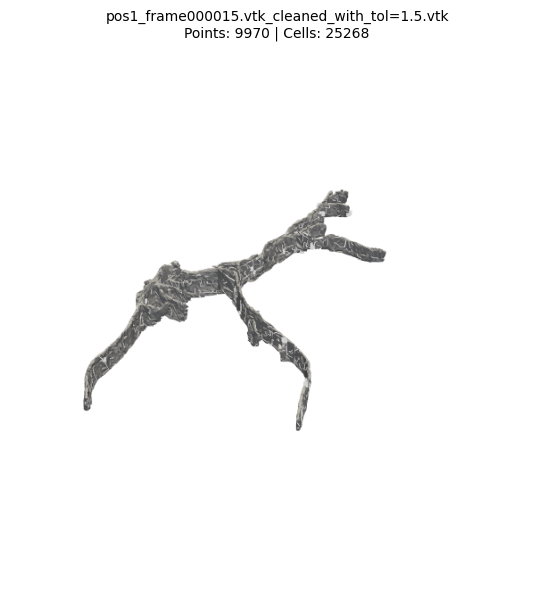

In [11]:
# Import libraries
import pyvista as pv
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# LOAD VTK FILE
# ============================================================
# Change this filepath to view another .vtk
file_path = Path(r"..\Data\Cleaned .vtk's\pos1_frame000015.vtk_cleaned_with_tol=1.5.vtk")
mesh = pv.read(file_path)

# ---- Mesh Info ----
print(f"Loaded: {file_path.name}")
print(f"Points: {mesh.n_points}")
print(f"Cells: {mesh.n_cells}")

print("\nPoint Data:", list(mesh.point_data.keys()))
print("Cell Data:", list(mesh.cell_data.keys()))
print("Field Data:", list(mesh.field_data.keys()))

# ============================================================
# TRUE STATIC 3D SCREENSHOT (NO VTK WINDOW)
# ============================================================

plotter = pv.Plotter(off_screen=True, window_size=(600, 600))

plotter.add_mesh(
    mesh,
    color="lightgray",
    show_edges=False
)

plotter.view_isometric()

img = plotter.screenshot(return_img=True)

plotter.close()

# ============================================================
# DISPLAY IMAGE ONLY
# ============================================================

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")

plt.title(
    f"{file_path.name}\nPoints: {mesh.n_points} | Cells: {mesh.n_cells}",
    fontsize=10
)

plt.tight_layout()
plt.show()